# Chapter 6. Ensemble Learning and Random Forests

We will often use ensemble methods near the end of a project, once we have already built a few good predictors, to combine them into even better predictor.

In [6]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# 1. Voting Classifiers

***Hard voting classifier***: the class that gets the most votes is the ensemble's prediction.
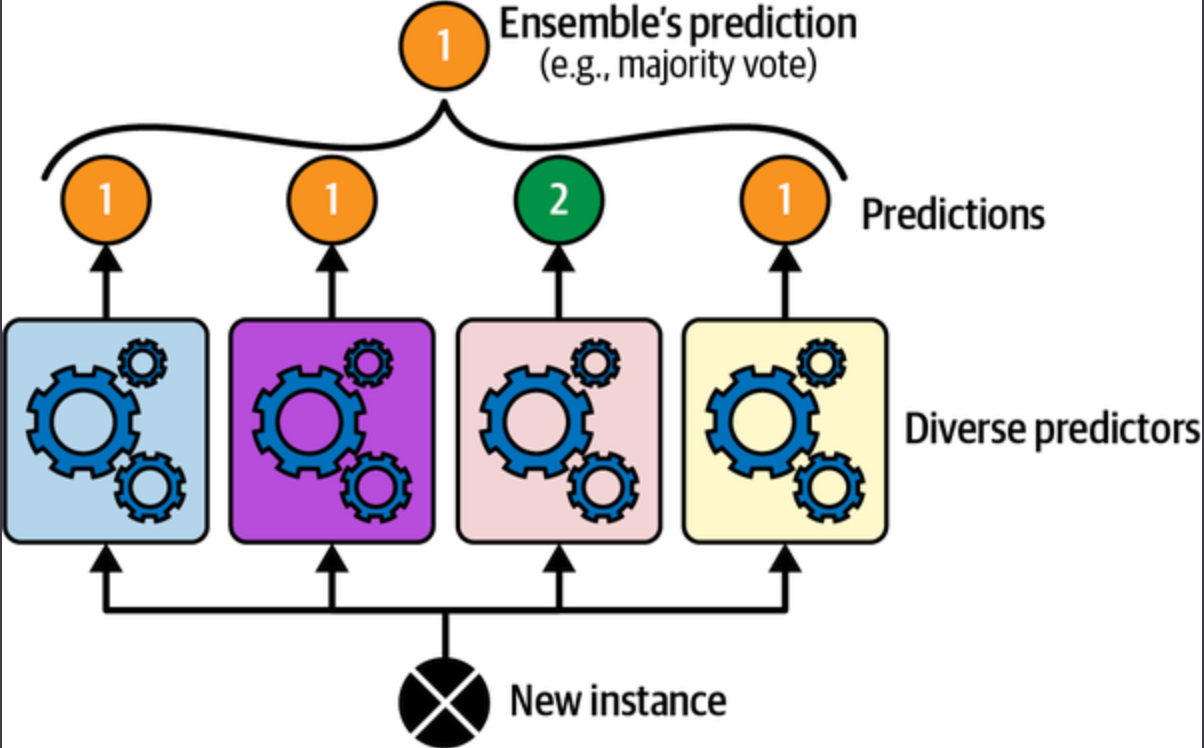

Ensemble methods work best when the predictors are as **independent** from one another as possible. One way to get diverse classifiers is to train them using very different algorithms. This increases the chance that they will make very different types of errors, improving the emsemble's accuracy. We can also tune hyperparameters to get diverse models, or train the models on different subsets of the data.

In [7]:
X, y = make_moons(n_samples=500, noise=0.3, random_state=32)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=32)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=32)),
        ('rf', RandomForestClassifier(random_state=32)),
        ('svc', SVC(random_state=32))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=32)),
                             ('rf', RandomForestClassifier(random_state=32)),
                             ('svc', SVC(random_state=32))])

In [8]:
for name, clf in voting_clf.named_estimators_.items():
    print(f'The {name} classifier has an accuracy of {clf.score(X_test, y_test)}')
# 'dir()' can be used to show all attributes of an object (e.g., voting_clf)
print(f'The ensemble classifier has an accuracy of {voting_clf.score(X_test, y_test)}')

The lr classifier has an accuracy of 0.88
The rf classifier has an accuracy of 0.928
The svc classifier has an accuracy of 0.92
The ensemble classifier has an accuracy of 0.928


In [9]:
voting_clf.predict(X_test[[4]])

array([1])

In [10]:
[clf.predict(X_test[[4]]) for clf in voting_clf.named_estimators_.values()]

[array([0]), array([1]), array([1])]

***Soft voting***: If all classifiers can estimate class probabilities, it is prefer to predict the class with the **highest class probability, averaged over all the individual classifiers**. It often achieves higher performance than hard voting because it gives more weight to highly confident votes.

In [11]:
voting_clf_soft = VotingClassifier(
    estimators = [
        ('lr', LogisticRegression(random_state=32)),
        ('rf', RandomForestClassifier(random_state=32)),
        ('svc', SVC(random_state=32, probability=True))
    ]
)
voting_clf_soft.fit(X_train, y_train)
voting_clf_soft.score(X_test, y_test)

0.928

## 2. Bagging and Pasting

One way to get diverse classifiers is to use the same training algorithm for every predictor but train them on different random subsets of the training set.
- When sampling is performed **with replacement** -> ***Bagging***
    - Prefer bagging when dataset is noisy / model is prone to overfitting, because bagging would introduce more diversity, though this ends up with a slighly higher bias than pasting; but the extra diversity also let the predictors being less correlated, so the emsemble's variance is reduced. Overall, **bagging often results in better models**.
    -  In practice, bagging is used far more often than pasting because bagging offers ***out-of-bag (OOB) evaluation***. Because sampling is done with replacement, on average about 37% of the training instances are never drawn into a given subset. These OOB instances serve as a ready-made validation set for the predictor trained on that subset, so you can estimate generalization performance without setting aside a seperate validation set. Pasting cannot offer this.
        - Where the 37% comes from: the probability that a particular instance (training set size: m) is never picked across n draws with replacement is (1−1/m)**n (sciket-learn default: m=n), when m (and n) increase, it approaches e**(-1) ~= 0.368.
- When sampling is performed **without replacement** -> ***Pasting***
    - Pasting avoids redundancy (because every sample possess 'new information'ZQ) and has a bit more computationally efficient.

In practice, the ensemble often ends up with a similar bias but **a lower variance** than a single predictor trained on the original training set. So it works best with high-variance and low-bias models (e.g., ensemble of decision trees, not ensemble of linear regressors).

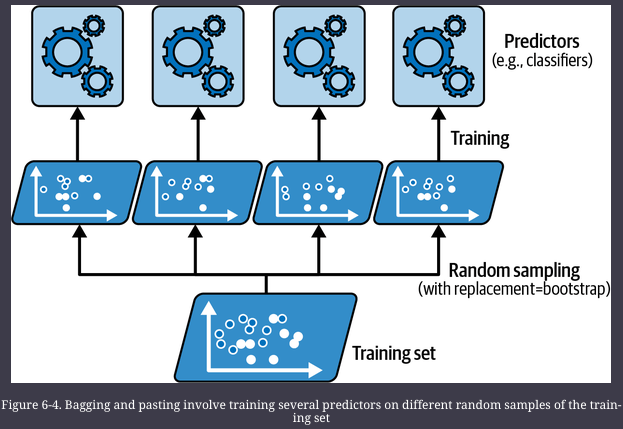

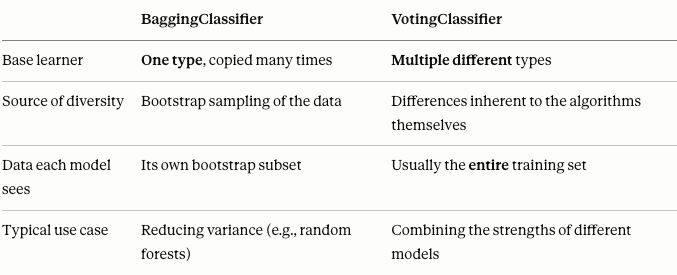

### 2.1. Bagging and Pasting in Scikit-Learn

In [13]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=1.0, random_state=32)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=500,
                  random_state=32)

A `BaggingClassifier` automatically performs soft voting instead of hard voting if the base classifier can estimate class probabilities (e.g., decision tree classifier).

### 2.2. Out-of-Bag Evaluation

In [19]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=1.0, random_state=32, 
                            oob_score=True) # OOB score parameter
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.8906666666666667

In [16]:
bag_clf.score(X_test, y_test)

0.936

### 2.3. Random Patches and Random Subspaces

`BaggingClassifier` supports sampling **features** as well, which is useful for high-dimensional inputs (such as images). 
- `max_features`
- `bootstrap-features`
<br>

**Sampling features introduces even more predictor diversity**, trading a bit more bias for a lower variance.
<br>

***Random patches method***: sampling both training instances and features.
<br>

***Random subspaces method***: keeping all training instances but sampling features.

## 3. Random Forests

A ***random forest (RF)*** is an ensemble of decision trees, generally trained via the bagging method, with `max_samples` set to the size of the training set. 
<br>

We can directly use `RandomForestClassifier` (also `RandomForestRegressor` for regression trees) instead of building a `BaggingClassifier` and passing it a `DecisionTreeClassifier` - convenient and optimized for decision trees.

In [21]:
rf_clf = RandomForestClassifier(n_estimators=500, random_state=32)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

The `RandomForestClassifier` automatically introduces extra randomness through search for the best feature among **a random subset (sqrt(n)) of features** (where n is the total number of features), which trades a higher bias for a lower variance.

### 3.1. Extra-Trees

***Extremely randomized trees***: We can make trees even more random by using **random thresholds for each feature** instead of searching for the best possible threshoulds by using `ExtraTreesClassifier` class. -> trade more bias for lower variance.

### 3.2. Feature Importance

## 4. Boosting

### 4.1. AdaBoost

### 4.2. Gradient Boosting

### 4.3. Histogram-Based Gradient Boosting

## 5. Stacking